# 02 â€” Data Exploration

**Project:** Ecommerce-LLM-Finetuning
**Goal of this notebook:**
1. Load the raw dataset saved by notebook 01
2. Inspect structure, nulls, and duplicates
3. Visualize class/category distribution
4. Analyze conversation (instruction/response) length
5. Generate a word cloud of common terms
6. Plot token-length distribution using the target model's tokenizer

Run this after `01_download_dataset.ipynb`.


In [1]:
# Install lightweight deps (Colab-safe)
!pip install -q wordcloud matplotlib seaborn pandas transformers sentencepiece


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Program Files\Python313\Scripts\pip.exe\__main__.py", line 2, in <module>
  File "C:\Users\Asus\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\Lib\re.py", line 125, in <module>
    import sre_compile
  File "C:\Users\Asus\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\Lib\sre_compile.py", line 17, in <module>
    assert _sre.MAGIC == MAGIC, "SRE module mismatch"
AssertionError: SRE module mismatch


In [ ]:
import os, sys, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def get_logger(name: str = "ecommerce_llm", level: int = logging.INFO) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(level)
    if not logger.handlers:
        handler = logging.StreamHandler(sys.stdout)
        formatter = logging.Formatter(
            "%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
            datefmt="%H:%M:%S",
        )
        handler.setFormatter(formatter)
        logger.addHandler(handler)
    return logger


def word_count(text: str) -> int:
    return len(text.split()) if isinstance(text, str) else 0


logger = get_logger("notebook02")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Load raw dataset

In [7]:
raw_path = cfg.raw_data_dir / "ecommerce_support_raw.csv"
df = pd.read_csv(raw_path)
print(f"Loaded {len(df):,} rows")
df.head()


Loaded 26,872 rows


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## 2. Basic statistics & null values

In [8]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe(include="all").T


Shape: (26872, 5)

Column dtypes:
 flags          object
instruction    object
category       object
intent         object
response       object
dtype: object

Null counts:
 flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Duplicate rows: 0


,count,unique,top,freq
flags,26872,394,BL,5212
instruction,26872,24635,shipments to {{Delivery City}},8
category,26872,11,ACCOUNT,5986
intent,26872,27,edit_account,1000
response,26872,26870,"Firstly, I truly understand how pivotal the {{...",2


## 3. Category / class distribution

If the dataset includes a `category`/`intent` column, visualize its distribution â€” useful for spotting class imbalance.

C:\Users\Asus\AppData\Local\Temp\ipykernel_23308\1851123916.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=cat_col, order=order, palette="viridis")


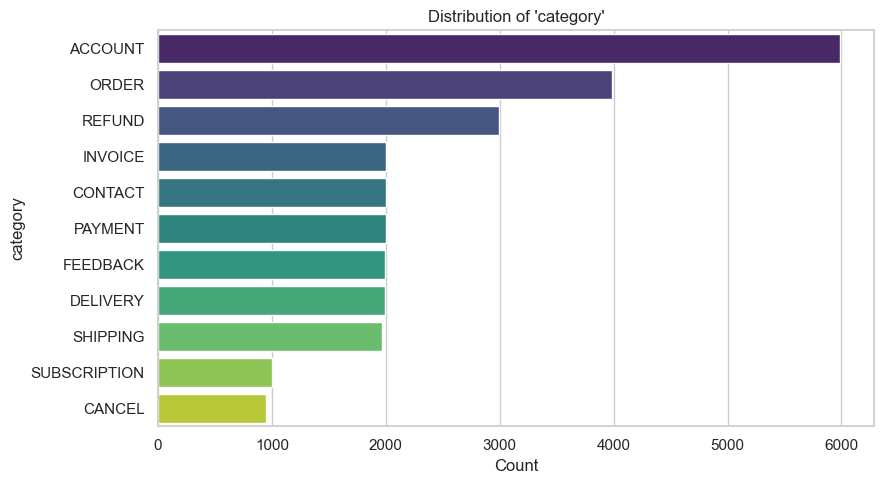

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


In [9]:
cat_col = None
for candidate in ["category", "intent", "topic", "label"]:
    if candidate in df.columns:
        cat_col = candidate
        break

if cat_col:
    plt.figure()
    order = df[cat_col].value_counts().index
    sns.countplot(data=df, y=cat_col, order=order, palette="viridis")
    plt.title(f"Distribution of '{cat_col}'")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()
    print(df[cat_col].value_counts())
else:
    print("No category-like column found â€” skipping class distribution plot.")


## 4. Conversation length analysis

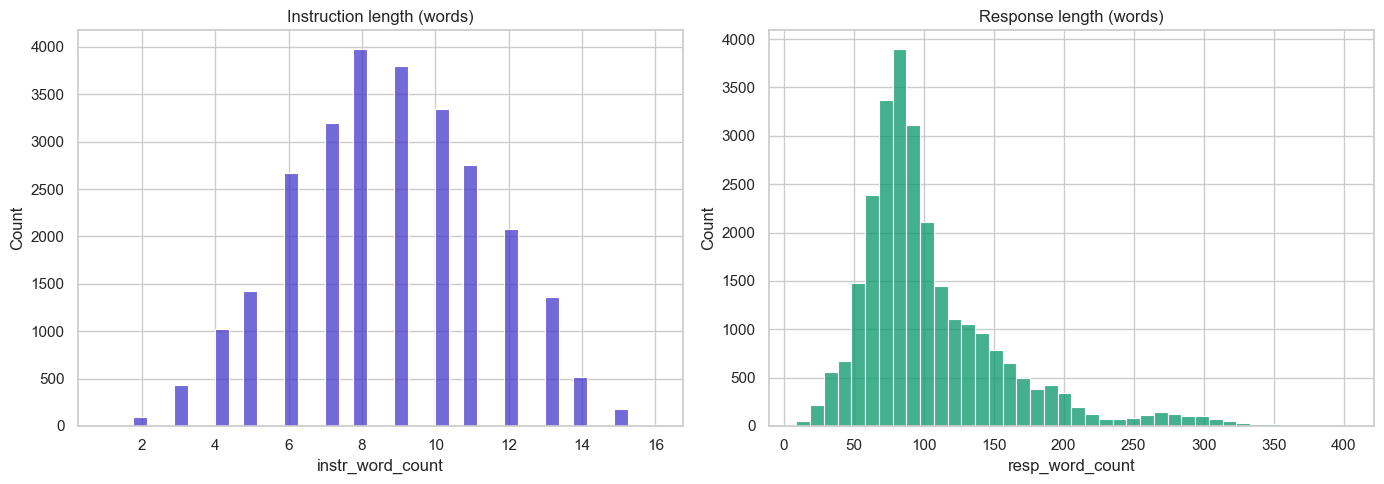

       instr_word_count  resp_word_count
count      26872.000000     26872.000000
mean           8.690979       104.789037
std            2.605004        52.966204
min            1.000000         9.000000
25%            7.000000        72.000000
50%            9.000000        90.000000
75%           11.000000       124.000000
max           16.000000       402.000000


In [10]:
instr_col = next((c for c in ["instruction", "question", "customer"] if c in df.columns), df.columns[0])
resp_col = next((c for c in ["response", "answer"] if c in df.columns), df.columns[1])

df["instr_word_count"] = df[instr_col].apply(word_count)
df["resp_word_count"] = df[resp_col].apply(word_count)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["instr_word_count"], bins=40, ax=axes[0], color="#4338ca")
axes[0].set_title("Instruction length (words)")
sns.histplot(df["resp_word_count"], bins=40, ax=axes[1], color="#059669")
axes[1].set_title("Response length (words)")
plt.tight_layout()
plt.show()

print(df[["instr_word_count", "resp_word_count"]].describe())


## 5. Word cloud of common terms

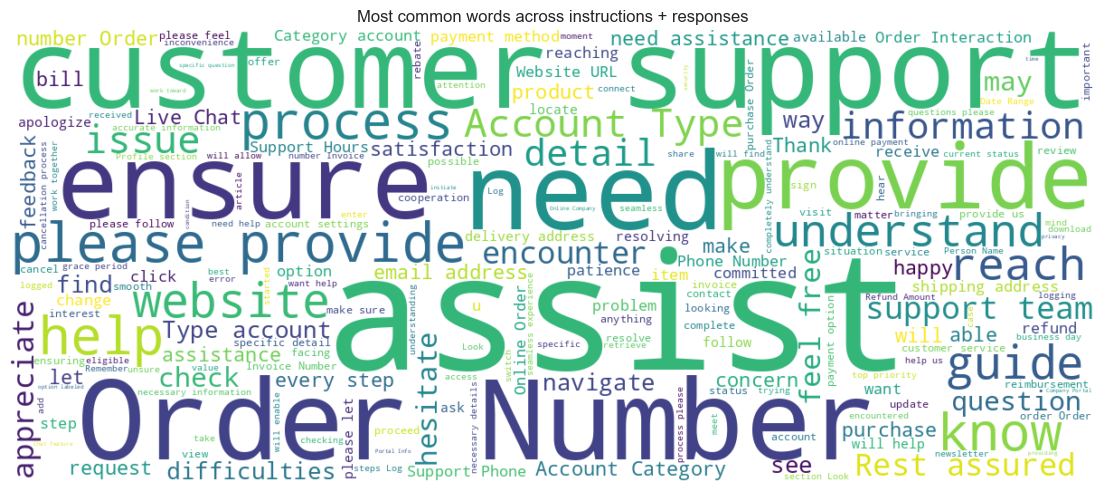

In [11]:
from wordcloud import WordCloud

all_text = " ".join(df[instr_col].astype(str).tolist() + df[resp_col].astype(str).tolist())
wc = WordCloud(width=1200, height=500, background_color="white", colormap="viridis").generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most common words across instructions + responses")
plt.show()


## 6. Token distribution (using the target model tokenizer)

We use the tokenizer for the model we plan to fine-tune (see `Config.base_model_name`) so length statistics reflect real training sequence lengths.

Loaded tokenizer: unsloth/Llama-3.2-3B-Instruct-bnb-4bit  (use_fast=True)


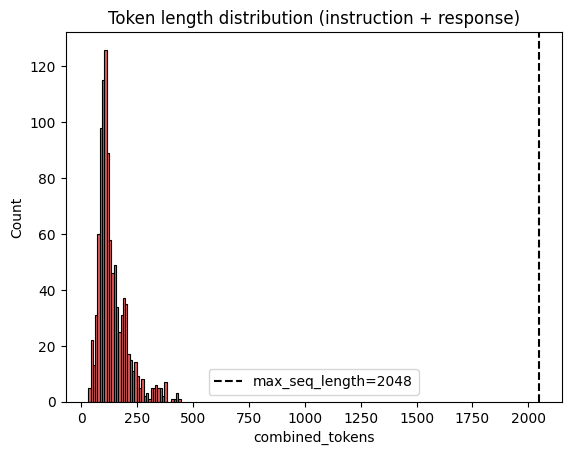

count    1000.000000
mean      138.413000
std        67.812336
min        31.000000
25%        95.000000
50%       116.000000
75%       169.000000
max       444.000000
Name: combined_tokens, dtype: float64

% of samples exceeding max_seq_length: 0.00%


In [12]:
from transformers import AutoTokenizer
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath('..'))
from src.config import Config
from src.utils import get_logger

cfg = Config()
logger = get_logger('notebook02')

# unsloth 4-bit repo names sometimes require the base repo tokenizer;
# fall back gracefully through several options if the tokenizer
# isn't directly loadable outside of Unsloth.
_tokenizer_candidates = [
    (cfg.base_model_name, {}),
    (cfg.base_model_name, {"use_fast": False}),
    ("unsloth/Llama-3.2-1B-Instruct", {}),
    ("unsloth/Llama-3.2-1B-Instruct", {"use_fast": False}),
    ("gpt2", {}),  # last-resort public tokenizer
]

tokenizer = None
for _name, _kwargs in _tokenizer_candidates:
    try:
        tokenizer = AutoTokenizer.from_pretrained(_name, **_kwargs)
        print(f"Loaded tokenizer: {_name}  (use_fast={_kwargs.get('use_fast', True)})")
        break
    except Exception as e:
        logger.warning(f"Could not load tokenizer {_name!r} ({_kwargs}): {e}")

if tokenizer is None:
    raise RuntimeError("No tokenizer could be loaded -- check your environment.")

if 'df' not in locals():
    import pandas as pd
    df = pd.read_csv(cfg.raw_data_dir / 'ecommerce_support_raw.csv')
instr_col = 'instruction'
resp_col = 'response'

sample_df = df.sample(min(len(df), 1000), random_state=cfg.seed)
sample_df["combined_tokens"] = (
    sample_df[instr_col].astype(str) + " " + sample_df[resp_col].astype(str)
).apply(lambda t: len(tokenizer(t)["input_ids"]))

plt.figure()
sns.histplot(sample_df["combined_tokens"], bins=40, color="#dc2626")
plt.axvline(cfg.max_seq_length, color="black", linestyle="--", label=f"max_seq_length={cfg.max_seq_length}")
plt.title("Token length distribution (instruction + response)")
plt.legend()
plt.show()

print(sample_df["combined_tokens"].describe())
print(f"\n% of samples exceeding max_seq_length: "
      f"{(sample_df['combined_tokens'] > cfg.max_seq_length).mean() * 100:.2f}%")


## Summary

- Reviewed dataset shape, nulls, and duplicates
- Visualized category balance (if available)
- Confirmed instruction/response lengths are reasonable for `max_seq_length`
- Token distribution shows very few (if any) sequences need truncation

Next: `03_preprocessing.ipynb` to clean the text and build instruction-response pairs.